In [1]:
import sys, os
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
import matplotlib.pyplot as plt
from pygimli.physics import ERTManager
from pygimli.physics import ert
from sys import path

fs=10
cMine = 100 
cMaxe = 10000
cMape = 'plasma_r' #'Spectral_r'   # Color scale

# Functions

In [2]:
### BUILD SYNTHETIC GEOMETRY AND ATTRIBUTE RESISTIVITIES #################################
def build_world(spacing):
    worldx = [(47*spacing)+(6*spacing), 0] #[xmax, xmin]
    worldz = [0, -int((np.max(worldx)/2.8))] #[zmax, zmin]
    print('Profile length: ',np.max(worldx))
    print('Profile depth: ',np.min(worldz))
    return worldx, worldz

def addRegionMarkers(interfaces):
    rm = [[5, interfaces[0]+2]] #positions (x, z) of region markers for all layers
    if len(interfaces) > 1:
        for i in range(len(interfaces)):
            rm = np.vstack((rm, [5, interfaces[i]+2]))
        rm = np.vstack((rm, [5, -20]))
    else:
        rm = np.vstack((rm, [5, -20]))
    return rm

def to_mesh(data, mesh):
    return data[mesh.cellMarkers()]

def buildSynGeometry(worldx, worldz, spacing, interfaces, rm, area, poly1, polyres, rmpoly, layerres):
    senposmin = np.min(worldx)+(3*spacing) #position first sensor (within worldx)
    sensors = np.arange(senposmin, senposmin+(48*spacing), spacing, dtype="float")
    # print("Sensor spacing: ", sensors[1]-sensors[0], " m")

    world = mt.createWorld(worldz, worldx, layers=interfaces, worldMarker=False)
    
    # ADD POLYGONS
    if 'rmpoly' in locals():
        rm = np.vstack((rm, rmpoly))
        # print('rm+poly ',rm)
        layerres = np.append(layerres,polyres)
        p1 =  mt.createPolygon(poly1, isClosed=True)
        geom = mt.mergePLC([world, p1])
        # p2 =  mt.createPolygon(poly2, isClosed=True)
        # geom = mt.mergePLC([world, p1, p2])
    else:
        geom = world
    
    for i in range(len(rm)):
        geom.addRegionMarker(rm[i], i)  
    mesh = mt.createMesh(geom, area=area)
    world=geom
    #pg.show(mesh, markers=True, showMesh=True)
    #geom.save(f'{path_SYN_data}/data/SYN_data/{case}_geom.bms')
    return world, mesh, sensors, layerres, rm

### MESH Functions ######################################################################
def createFwdMesh(ertScheme, paraDX, paraMaxCellSize, mesh, rhotrue, noiselevel, cMape, cMine, cMaxe):
    # Create suitable mesh for ert forward calculation
    meshERTFWD = mt.createParaMesh(ertScheme, paraDX=paraDX, paraMaxCellSize=paraMaxCellSize,
                                boundaryMaxCellSize=70, paraBoundary=2,boundary=1, quality=33.8)
    #pg.show(meshERTFWD)

    res = pg.Vector()
    pg.interpolate(mesh, rhotrue, meshERTFWD.cellCenters(), res)
    res = mt.fillEmptyToCellArray(meshERTFWD, res, slope=True)
    ertm.setMesh(meshERTFWD)
    ertm.fop.createRefinedForwardMesh()
    ertData = ertm.simulate(mesh=meshERTFWD, scheme=ertScheme, res=res, noiseLevel=noiselevel, noiseAbs=0.0)
    #ertData.save(f'{path_SYN_data}/data/SYN_data/{case}_erttrue.dat')

    ertm.setData(ertData)
    ertm.setMesh(meshERTFWD)
    ertm.inv.dataVals = ertData("rhoa")
    # pg.show(ertData, cMap=cMape, cMin=cMine, cMax=cMaxe, orientation='vertical')
    return ertData

def createInvMesh(ertData, worldz, paraDX,paraMaxCellSize, area, xbound, ybound):
    plc = mt.createParaMeshPLC(ertData, paraDepth=np.min(worldz), paraDX=paraDX,     
                            paraBoundary=2, boundary=0, paraMaxCellSize=paraMaxCellSize)

    for sensor in ertData.sensorPositions():
        plc.createNode([sensor.x(), sensor.y() - 0.1])

    meshERT0 = mt.createMesh(plc, quality=33.8, area=area, smooth=True) 
    for cell in meshERT0.cells():
        cell.setMarker(2)
    for boundary in meshERT0.boundaries():
        boundary.setMarker(0)
    # pg.show(meshERT0)

    meshERT = mt.appendTriangleBoundary(meshERT0, xbound=xbound, ybound=ybound,
                                        quality=33.8, isSubSurface=True)
    # pg.show(meshERT)
    return meshERT, meshERT0

### SIMULATE DATA FUNCTION ######################################
def simulateData(ERT_config, sensors):
    if ERT_config == 'dd': 
        dd_spacings=[1,3,5,7,9,12] #only for dd
        ertScheme = ert.createData(sensors, ERT_config, spacings=dd_spacings)
    else: 
        ertScheme = ert.createData(sensors, ERT_config)
    k = ert.geometricFactors(ertScheme)
    ertScheme.markInvalid(pg.abs(k) > 5000)
    ertScheme.removeInvalid()
    ertm = ERTManager()
    return ertm, ertScheme


## PART I
# 1 Create Synthetic Model
1.1 Geometry

In [3]:
case='Test_TP5' # case title

# Model geometry & characteristics 
spacing = 2 #sensor spacing [m] 

interfaces = [-5] #depth of interface(s)

poly1 = [[35*spacing,  interfaces[0]-5], [15*spacing,  interfaces[0]-5], [15*spacing, interfaces[0]], [35*spacing, interfaces[0]]] #[[x1,z1], [x2,z2], ..., [xn,zn]]
rmpoly = ([poly1[1][0]+5, poly1[1][1]+2]) #positions (x, z) of region markers for all polygons

# Attribute Resistivities to Layers and Polygons
layerres = np.array([600, 2500]) # resistivity for each layer
polyres  = 10 # resistivity for each polygon

1.2 Mesh

Profile length:  159
Profile depth:  -56


(<Axes: xlabel='$x$ in m', ylabel='$y$ in m'>,
 <matplotlib.colorbar.Colorbar at 0x7f62718b4e50>)

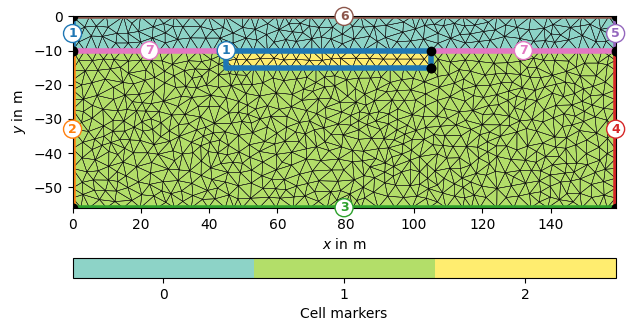

In [13]:
# CREATE UNSTRUCTURED MESH FROM SYNTHETIC GEOMETRY
worldx, worldz = build_world(spacing)
area = 3*spacing # size of triangles (square meters) 

rm = addRegionMarkers(interfaces) #add region markers

world, mesh, sensors, layerres, rm = buildSynGeometry(worldx, worldz, spacing, interfaces, rm, area, poly1, polyres, rmpoly, layerres)
# print('region markers: ', rm)

rhotrue = to_mesh(layerres, mesh) # attribute resistivities to layers
    
pg.show(mesh, markers=True, showMesh=True)


1.3 Plot Synthetic Model

Number of layers:  6
Layer resistivity (Ωm):  [2500.  600.   10.   10.   10.   10.]


Text(50, -13, '10 $\\Omega$m')

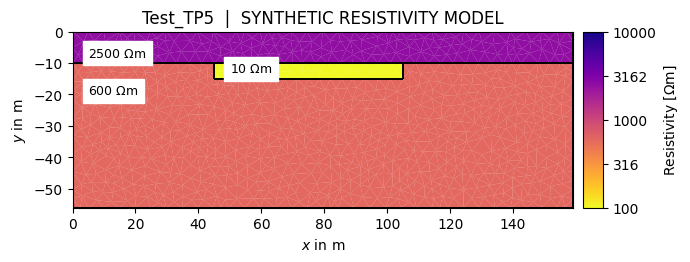

In [14]:
print("Number of layers: ", len(layerres))
print("Layer resistivity (\u03A9m): ", np.rint(layerres))


# Plot SYN RES
fig, ax = pg.plt.subplots(1,1,figsize=(7,4))
pg.show(ax=ax, mesh=mesh, data=rhotrue, logScale=True, label='Resistivity [$\Omega$m]', cMin=cMine, cMax=cMaxe, cMap=cMape, orientation='vertical')
ax.set_title(case+ "  |  SYNTHETIC RESISTIVITY MODEL")
tr1, tr2, tr3 ="%.0f $\Omega$m" % np.rint(layerres[0]), "%.0f $\Omega$m" % np.rint(layerres[1]), "%.0f $\Omega$m" % np.rint(layerres[2])
ax.text(rm[0][0],rm[0][1], tr1, size=9, backgroundcolor='white')
ax.text(rm[1][0],rm[1][1], tr2, size=9, backgroundcolor='white')
ax.text(rm[2][0],rm[2][1], tr3, size=9, backgroundcolor='white')


# 2 Simulate apparent resistivities (Forward Modelling)

--> Result: Pseudosection (= calculated measured (apparent) resistivities for a hypothetic survey with hypothetic electrode spacing and configuration)

01/04/26 - 17:21:49 - pyGIMLi - INFO - Cache /layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.0s x 2): /home/renku/.cache/pygimli/4226849357409561268
01/04/26 - 17:21:49 - pyGIMLi - INFO - Found 2 regions.
01/04/26 - 17:21:49 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/04/26 - 17:21:49 - Core - INFO - Create H2 refined mesh for forward tasks.
01/04/26 - 17:21:50 - pyGIMLi - INFO - Data error estimate (min:max)  0.02 : 0.02
01/04/26 - 17:21:50 - pyGIMLi - INFO - Found 2 regions.
01/04/26 - 17:21:50 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


ModellingBase::setMesh() copying new mesh ... Found datafile: 48 electrodes
Found: 48 node-electrodes
rMin = 1.5, rMax = 282
NGauLeg + NGauLag for inverse Fouriertransformation: 13 + 4
Found non-Neumann domain
0.0199549 s
FOP updating mesh dependencies ... 2.195e-06 s
Calculating response for model: min = 16.4988 max = 2500
Allocating memory for primary potential...... 0.00133737

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.333012s
Response: min = 555.723 max = 2470.77 mean = 1450.07
Reciprocity rms(modelReciprocity) 0.146176%, max: 0.431803%


(<Axes: >, <matplotlib.colorbar.Colorbar at 0x7f6278609210>)

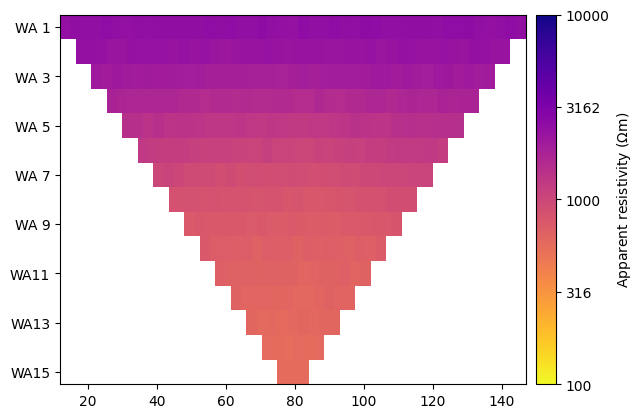

In [15]:
### Some settings ###################
paraDX = 1
paraMaxCellSize = 15*spacing
noiselevel = 0.02 # add relative noise to the simulated data. noiseLevel*100 in % (0.025 = 2.5 %)
xbound = 100
ybound = 100

#ERT
lamERT = 10
zWeightERT = 0.2
maxIterERT = 6

# ERT Config
ERT_config = 'wa' #other schemes ['wa', 'dd', 'slm']

# Simulate Data
ertm, ertScheme = simulateData(ERT_config, sensors)

# Create Mesh for ERT Forward Calculation
ertData = createFwdMesh(ertScheme, paraDX, paraMaxCellSize, mesh, rhotrue, noiselevel, cMape, cMine, cMaxe)
pg.show(ertData, cMap=cMape, cMin=cMine, cMax=cMaxe, orientation='vertical')

# 3 Inversion (Inverse modelling)

3.1 Mesh generation

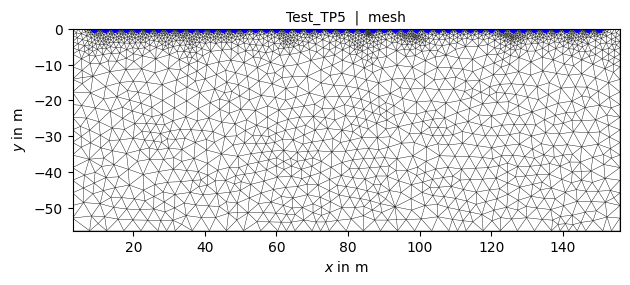

In [16]:
# create MESH for Inversion 
meshERT, meshERT0 = createInvMesh(ertData, worldz, paraDX, paraMaxCellSize, area, xbound, ybound)

fig, ax = pg.plt.subplots()
pg.show(meshERT0, showMesh=True, markers=False, ax=ax, hold=True)
ax.set_title(case+'  |  mesh',fontsize=fs)
ax.plot(pg.x(ertData.sensorPositions()), pg.z(ertData.sensorPositions()), "b.", ms=8, label="Electrodes")


3.2 Inversion (this cell may take some time to run)

--> Result: Tomogram with true (specific) resistivites (should ideally be similar to the synthetic model)


01/04/26 - 17:20:33 - pyGIMLi - INFO - Found 2 regions.
01/04/26 - 17:20:33 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/04/26 - 17:20:33 - pyGIMLi - INFO - Creating forward mesh from region infos.
01/04/26 - 17:20:33 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/04/26 - 17:20:33 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 6990 Cells: 13140 Boundaries: 10274
01/04/26 - 17:20:33 - pyGIMLi - INFO - Use median(data values)=770.1024366871502


array([<Axes: >, <Axes: >], dtype=object)

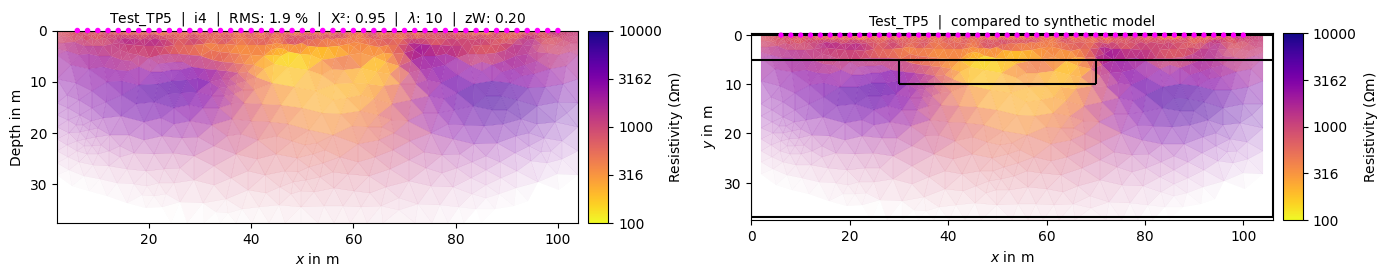

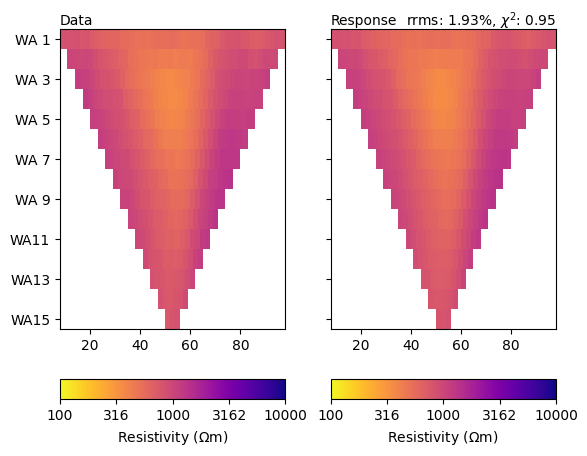

In [8]:
# Inversion
ertm.setMesh(meshERT)
resinv = ertm.invert(ertData, lam=lamERT, zWeight=zWeightERT, maxIter=maxIterERT, showProgress=False) #showProgress=True
rmschi1=f'i{len(ertm.inv.chi2History)}  |  RMS: {ertm.inv.relrms():.1f} %  |  \u03A7\N{superscript two}: {ertm.inv.chi2():.2f}  |  $\lambda$: {lamERT:.0f}  |  zW: {zWeightERT:.2f}'

# Plot Inversion Result
fig, axes = pg.plt.subplots(1,2,figsize=(14,7))
ax=axes[0]
ertm.showResult(resinv,ax,logScale=True, cMin=cMine, cMax=cMaxe, cMap=cMape, orientation='vertical')
ax.set_title(case+"  |  "+rmschi1, fontsize = fs)
ax=axes[1]
ertm.showResult(resinv,ax,logScale=True, cMin=cMine, cMax=cMaxe, cMap=cMape, orientation='vertical')
pg.show(mesh=world, ax=ax, fillRegion=False, regionMarker=False) #show synthetic geometry (world) on top of inverted data
ax.set_title(case+"  |  compared to synthetic model", fontsize = fs)

# plot data misfit
# ertm.showResultAndFit(cMin=cMine, cMax=cMaxe, cMap=cMape, title=case+"  |  "+rmschi1)
ertm.showFit(cMin=cMine, cMax=cMaxe, cMap=cMape, title=case+"  |  "+rmschi1)


### ______________________________________
## PART II

# 4 NOW IT'S YOUR TURN:
 
## 4.1 Adjust the synthetic model step by step and discover how the tomogram changes (follow the instructions in the exercise)

a) Depth of the interface (try -15 m)   
b) Layer resistivities (try different resistivity contrasts),    
c) Electrode spacing (try 5m spacing),    
d) Electrode configuration (try Dipole-Dipole instead of Wenner)   


In [9]:
# a) Change the value for the depth of the interface:
interfaces = [-10]  #depth of interface(s)

# b) Change the values of the layer resistivities:
layerres = np.array([2500, 600])  # resistivity for each layer

# c) Change the sensor spacing:
spacing = 3  #sensor spacing [m] 

# d) Change the Electrode Configuration:
ERT_config = 'wa'  #possible configurations: 'wa' (Wenner) , 'dd' (dipole dipole), 'slm' (Wenner Schlumberger)

poly1 = [[35*spacing,  interfaces[0]-5], [15*spacing,  interfaces[0]-5], [15*spacing, interfaces[0]], [35*spacing, interfaces[0]]] #[[x1,z1], [x2,z2], ..., [xn,zn]]
rmpoly = ([poly1[1][0]+5, poly1[1][1]+2]) #positions (x, z) of region markers for all polygons
polyres  = 10 # resistivity for each polygon

### 4.2 Update mesh, Simulate data, and Invert the new model

01/04/26 - 17:20:46 - pyGIMLi - INFO - Cache /layers/paketo-buildpacks_pip-install/packages/lib/python3.11/site-packages/pygimli/physics/ert/ert.py:createGeometricFactors restored (0.0s x 1): /home/renku/.cache/pygimli/4226849357409561268
01/04/26 - 17:20:46 - pyGIMLi - INFO - Found 2 regions.
01/04/26 - 17:20:46 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/04/26 - 17:20:46 - Core - INFO - Create H2 refined mesh for forward tasks.


Profile length:  159
Profile depth:  -56


01/04/26 - 17:20:47 - pyGIMLi - INFO - Data error estimate (min:max)  0.02 : 0.02
01/04/26 - 17:20:47 - pyGIMLi - INFO - Found 2 regions.
01/04/26 - 17:20:47 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


ModellingBase::setMesh() copying new mesh ... Found datafile: 48 electrodes
Found: 48 node-electrodes
rMin = 1.5, rMax = 282
NGauLeg + NGauLag for inverse Fouriertransformation: 13 + 4
Found non-Neumann domain
0.0187889 s
FOP updating mesh dependencies ... 1.689e-06 s
Calculating response for model: min = 311.628 max = 2500
Allocating memory for primary potential...... 0.00128532

No primary potential for secondary field calculation. Calculating analytically...
Forward: time: 0.32307s
Response: min = 645.555 max = 2464.76 mean = 1507.23
Reciprocity rms(modelReciprocity) 0.0991922%, max: 0.284242%


01/04/26 - 17:20:47 - pyGIMLi - INFO - Found 2 regions.
01/04/26 - 17:20:47 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
01/04/26 - 17:20:47 - pyGIMLi - INFO - Creating forward mesh from region infos.
01/04/26 - 17:20:47 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/04/26 - 17:20:47 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 12050 Cells: 22876 Boundaries: 17768
01/04/26 - 17:20:47 - pyGIMLi - INFO - Use median(data values)=1411.520063080016


Text(0.5, 1.0, 'INVERTED SYNTHETIC DATA  |  electrode spacing: 3m | config: wa')

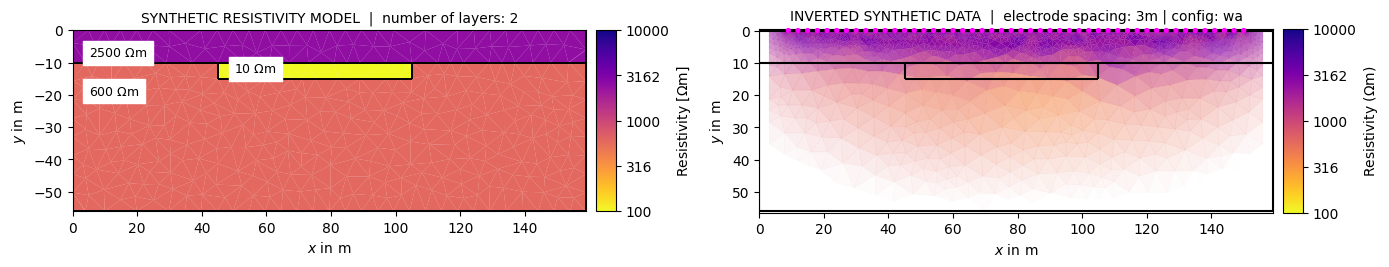

In [10]:
### UPDATE MESH ###################################
worldx, worldz = build_world(spacing)
area = 7*spacing # size of triangles (square meters) 
rm = addRegionMarkers(interfaces) #add region markers

world, mesh, sensors, layerres, rm = buildSynGeometry(worldx, worldz, spacing, interfaces, rm, area, poly1, polyres, rmpoly, layerres)

rhotrue = to_mesh(layerres, mesh) # attribute resistivities to layers
    
# pg.show(mesh, markers=True, showMesh=True)

### SIMULATE DATA ################################
ertm, ertScheme = simulateData(ERT_config, sensors)

# Create suitable mesh for ert forward calculation
paraMaxCellSize=15*spacing
ertData = createFwdMesh(ertScheme, paraDX, paraMaxCellSize, mesh, rhotrue, noiselevel, cMape, cMine, cMaxe)

# Create mesh for inversion
meshERT, _ = createInvMesh(ertData, worldz, paraDX,paraMaxCellSize, area, xbound, ybound)

### INVERSION ####################################
ertm.setMesh(meshERT)
resinv = ertm.invert(ertData, lam=lamERT, zWeight=zWeightERT, maxIter=maxIterERT, verbose=False)  #showProgress=True
rmschi1=f'i{len(ertm.inv.chi2History)}  |  RMS: {ertm.inv.relrms():.1f} %  |  \u03A7\N{superscript two}: {ertm.inv.chi2():.2f}  |  $\lambda$: {lamERT:.0f}  |  zW: {zWeightERT:.2f}'

### PLOT #########################################
fig, axes = pg.plt.subplots(1,2,figsize=(14,7))
ax=axes[0] # Plot SYN RES
pg.show(ax=ax, mesh=mesh, data=rhotrue, logScale=True, label='Resistivity [$\Omega$m]', cMin=cMine, cMax=cMaxe, cMap=cMape, hold=True, orientation='vertical')
ax.set_title("SYNTHETIC RESISTIVITY MODEL  |  number of layers: "+str(len(interfaces)+1), fontsize = fs)
tr1, tr2, tr3 ="%.0f $\Omega$m" % np.rint(layerres[0]), "%.0f $\Omega$m" % np.rint(layerres[1]), "%.0f $\Omega$m" % np.rint(layerres[2])
ax.text(rm[0][0],rm[0][1], tr1, size=9, backgroundcolor='white')
ax.text(rm[1][0],rm[1][1], tr2, size=9, backgroundcolor='white')
ax.text(rm[2][0],rm[2][1], tr3, size=9, backgroundcolor='white')
ax=axes[1]  # Plot Inverted SYN RES
ertm.showResult(resinv,ax,logScale=True, cMin=cMine, cMax=cMaxe, cMap=cMape, hold=True, orientation='vertical')
pg.show(mesh=world, ax=ax, fillRegion=False, regionMarker=False) #show syntheic geometry (world) on top of inverted data
ax.set_title("INVERTED SYNTHETIC DATA  |  electrode spacing: "+str(spacing)+"m | config: "+str(ERT_config), fontsize = fs)
